# 06 · Dataset Construction

**Purpose:** Align news features with market data and compute prediction targets.

**Alignment logic:**  
Features computed from articles published on day `d` are aligned with
the stock price on day `d`.  The target is the **next trading day's return**
(`close_{d+1} - close_d) / close_d`).
This ensures no look-ahead bias: you observe news today, predict tomorrow.

**Targets:**
- `next_day_return` — continuous return (regression)
- `direction` — 1 if `next_day_return > 0`, else 0 (classification)

**Input:** `features.parquet`, `stock_prices.parquet`  
**Output:** `modeling_dataset.parquet`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

NB_DIR = Path().resolve()
sys.path.insert(0, str(NB_DIR))
from utils import load, save

In [2]:
features     = load("features")
stock_prices = load("stock_prices")

print(f"Feature rows:    {len(features):,}")
print(f"Price rows:      {len(stock_prices):,}")

Feature rows:    892
Price rows:      42,702


## 1 · Compute returns and targets

In [3]:
def compute_targets(prices: pd.DataFrame) -> pd.DataFrame:
    df = prices.sort_values(["ticker", "date"]).copy()
    df["date"] = pd.to_datetime(df["date"])

    df["daily_return"]    = df.groupby("ticker")["close"].pct_change()
    df["next_day_return"] = df.groupby("ticker")["daily_return"].shift(-1)
    df["direction"]       = (df["next_day_return"] > 0).astype("Int64")

    return df.dropna(subset=["next_day_return"])


prices = compute_targets(stock_prices)
print(f"Price rows with targets: {len(prices):,}")
print(f"Direction balance: {prices['direction'].mean():.2%} up days")

Price rows with targets: 42,656
Direction balance: 41.95% up days


## 2 · Merge features with prices

In [4]:
features["date"] = pd.to_datetime(features["date"])

dataset = prices.merge(features, on=["ticker", "date"], how="left")

# Rows with no news signal on this day → fill with zero (no-news = neutral)
feature_cols = [c for c in features.columns if c not in ["ticker", "date"]]
dataset[feature_cols] = dataset[feature_cols].fillna(0)

news_days = (dataset["news_count"] > 0).sum()
print(f"Dataset shape:          {dataset.shape}")
print(f"Tickers:                {dataset['ticker'].nunique()}")
print(f"Date range:             {dataset['date'].min().date()} → {dataset['date'].max().date()}")
print(f"Rows with news signal:  {news_days:,} / {len(dataset):,} ({news_days/len(dataset):.1%})")

Dataset shape:          (42656, 75)
Tickers:                46
Date range:             2021-01-04 → 2026-05-12
Rows with news signal:  176 / 42,656 (0.4%)


## 3 · Return distribution

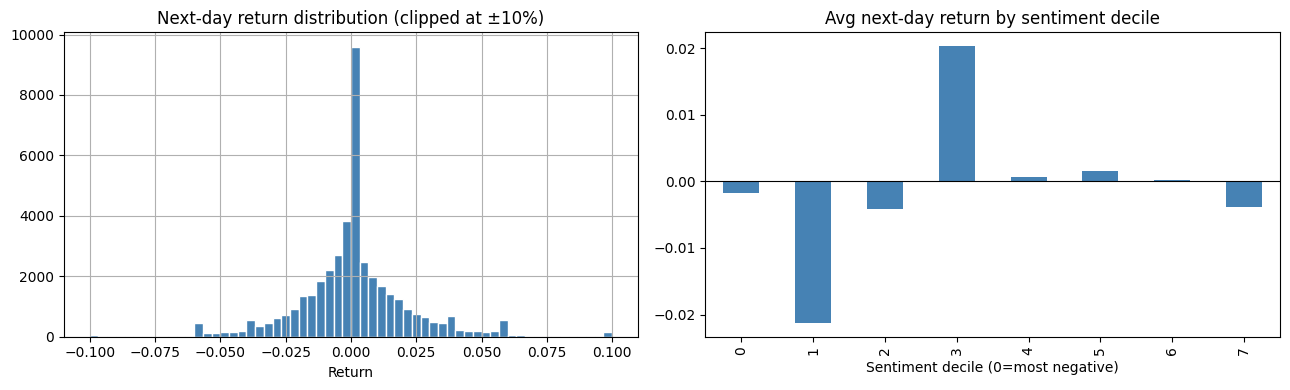

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

clipped = dataset["next_day_return"].clip(-0.1, 0.1)
clipped.hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Next-day return distribution (clipped at ±10%)")
axes[0].set_xlabel("Return")

# Avg sentiment vs avg next-day return (decile buckets)
no_zero = dataset[dataset["news_count"] > 0].copy()
no_zero["sent_decile"] = pd.qcut(no_zero["avg_sentiment"], q=10, labels=False, duplicates="drop")
bucket = no_zero.groupby("sent_decile")["next_day_return"].mean()
bucket.plot.bar(ax=axes[1], color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Avg next-day return by sentiment decile")
axes[1].set_xlabel("Sentiment decile (0=most negative)")

plt.tight_layout()
plt.show()

## 4 · Coverage summary per ticker

In [6]:
summary = dataset.groupby("ticker").agg(
    total_days   =("date", "count"),
    news_days    =("news_count", lambda x: (x > 0).sum()),
    avg_return   =("next_day_return", "mean"),
    std_return   =("next_day_return", "std"),
).assign(news_coverage=lambda d: (d["news_days"] / d["total_days"]).round(3))

print(summary.sort_values("news_days", ascending=False).head(20).to_string())

        total_days  news_days  avg_return  std_return  news_coverage
ticker                                                              
ADI           1333         12    0.002162    0.025162          0.009
ARD           1253         11    0.000208    0.014964          0.009
AFI           1104         10    0.000320    0.016526          0.009
RIS           1261         10    0.001108    0.022227          0.008
LES           1037         10    0.001045    0.022801          0.010
COL           1247         10    0.000880    0.021580          0.008
ATL           1309          9    0.000556    0.020209          0.007
IMO           1271          8    0.000054    0.011924          0.006
ADH           1334          8    0.001521    0.025118          0.006
INV            990          8    0.000632    0.029105          0.008
GAZ           1044          7    0.000193    0.020497          0.007
REB            335          7    0.000422    0.036170          0.021
BAL            348          6    0

In [7]:
dataset  = dataset[dataset['news_count'] > 0]
dataset

,ticker,date,close,open,high,low,volume,change_pct,daily_return,next_day_return,...,llm_evt_debt_issuance_r7d,llm_evt_earnings_release_r7d,llm_evt_economic_indicator_r7d,llm_evt_ipo_listing_r7d,llm_evt_leadership_change_r7d,llm_evt_market_data_r7d,llm_evt_other_r7d,llm_evt_project_contract_r7d,llm_evt_regulatory_action_r7d,llm_evt_strategic_plan_r7d
370,ADH,2022-06-24,7.65,7.75,7.75,7.60,51750.0,-1.03,-0.010349,-0.005229,...,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0
1316,ADH,2026-04-16,35.40,35.45,36.20,35.03,143760.0,0.31,0.003117,0.019774,...,0.0,0.0,0.0,0.0,0.0,0.0,1.571429,0.0,0.0,0.0
1317,ADH,2026-04-17,36.10,35.20,37.60,35.20,1690000.0,1.98,0.019774,-0.013850,...,0.0,0.0,0.0,0.0,0.0,0.0,2.142857,0.0,0.0,0.0
1318,ADH,2026-04-20,35.60,35.36,35.90,35.11,592670.0,-1.39,-0.013850,0.011236,...,0.0,0.0,0.0,0.0,0.0,0.0,4.142857,0.0,0.0,0.0
1319,ADH,2026-04-21,36.00,35.40,36.40,35.40,399400.0,1.12,0.011236,-0.013889,...,0.0,0.0,0.0,0.0,0.0,0.0,6.857143,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40946,TMA,2026-04-24,1501.00,1520.00,1520.00,1501.00,360.0,-1.25,-0.012500,-0.000666,...,0.0,0.0,0.0,0.0,0.0,0.0,1.166667,0.0,0.0,0.0
42139,WAA,2026-04-20,5270.00,5278.00,5278.00,5270.00,0.0,1.35,0.013462,0.024668,...,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0
42141,WAA,2026-04-22,5500.00,5400.00,5500.00,5400.00,80.0,1.85,0.018519,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.200000,0.0,0.0,0.0
42142,WAA,2026-04-23,5500.00,5500.00,5500.00,5500.00,60.0,0.00,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.666667,0.0,0.0,0.0


In [8]:
save(dataset, "modeling_dataset")

  saved 176 rows  →  modeling_dataset.parquet


WindowsPath('C:/_PROJECTS/pfa_bvc/Notebooks/signal_pipeline/data/modeling_dataset.parquet')